**Sarcasm Detection in News Headlines**

**Name- Sramana Bhattacharya**

**Student Id- GH1037191**

**Introduction-**

* Sarcasm is a difficult subject in natural language processing because of its background reality and intended meaning, where humans can understand sarcasm based on tones, facial expression and current information. This project is basically related to the news industry, as news headlines created by them usually involves sarcasm to engage the readers.
* The news organizations make their headlines in sarcastic way to avoid direct controversy. The sarcastic statements create an impact on human mind about the brands, companies, politics and personalities. Inappropriate classifications of contents fail the sentimental analysis and misguide the decisions.  
* This project solves the problem of automated sarcasm classification in news headlines by using and comparing three methods such as TF-IDF with Logistic Regression, Word2Vector and BERT.
* This research is motivated by practical application in setimental analysis and misinformation classification. Misclassifying content can result in inaccurate sentiment scoring for brand monitoring and distorted public opinion analysis.
* This model will help to assume automatically the sarcastic tones for the news paper headlines. This allows the sentimental analysis for particular brands or companies, political or famous figures.

**Aim-**

* To develop and eveluate machine learning models capable of determining is a particular piece of news is sarcastic or not.
* Implement a TF-IDF vectorization strategy with Logistic Regression to create a statistical baseline that captures word frequency.
* Create a word2Vector + RNN architecture to see sequential models.
* Fine-tune a pre-trained Bert model to check transformer evaluation.
* Compare the detection accuracy among various models.
* This model will be able to accurately predict the sentimental analysis of     media thoughts.
* Help reader to understand the approaching tone and controversial statements.

**Data Collection-**

* For this project the dataset has taken from kaggle. It contains 26,709 news headlines.
* The dataset has real-worlds news headlines with proper language.
* Dataset link: News Headlines Dataset For Sarcasm Detectection (Rishabh Misra, 2019) https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection


**Import Libraries**

In [ ]:
!pip install -q gensim transformers datasets
import json, re, warnings, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, f1_score
from gensim.models import Word2Vec
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import tqdm
from datasets import Dataset
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

torch.manual_seed(42)

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.9 MB/s eta 0:00:00


True

**Dataset Loading**

In [ ]:
data = []
with open ('/content/Sarcasm_Headlines_Dataset.json', 'r') as f:
  for line in f:
    try: data.append(json.loads(line))
    except: pass
  data = pd.DataFrame(data)

* The json file dataset is loaded here which will read the file line by line.
* Then it will convert into pandas dataframe.

**Data Cleaning and Preprocessing**

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean(text):
    text = re.sub(r'http\S+|www\S+|\W', ' ', text.lower())
    return ' '.join([lemmatizer.lemmatize(w) for w in text.split()
                    if w not in stop_words and len(w) > 2])

data['clean'] = data['headline'].apply(clean)
X_train, X_test, y_train, y_test = train_test_split(
data['clean'], data['is_sarcastic'], test_size=0.2, random_state=42, stratify=data['is_sarcastic'])

print(f"Dataset: {len(data)} | Train: {len(X_train)} | Test: {len(X_test)}\n")

Dataset: 26709 | Train: 21367 | Test: 5342



* The dataset has 26,709 news headlines collected from real world news.
* The `clean()` function is used here for cleaning every headline.
* All text are converted to lowercase and removed the urls from the headlines.
* Lemmatization was used to reduce words to their most besic form.
* The cleaned texts are stored in headline column and the preprocessed texts are stored in clean column.
* For repeatability, an 80-20 stratified train-test split has been created by using sckitlearn's with `random_state=42`.  

**Class Distribution**

Class Distribution
is_sarcastic
0    14985
1    11724
Name: count, dtype: int64

Balance: 43.9% sarcastic, 56.1% non_sarcastic


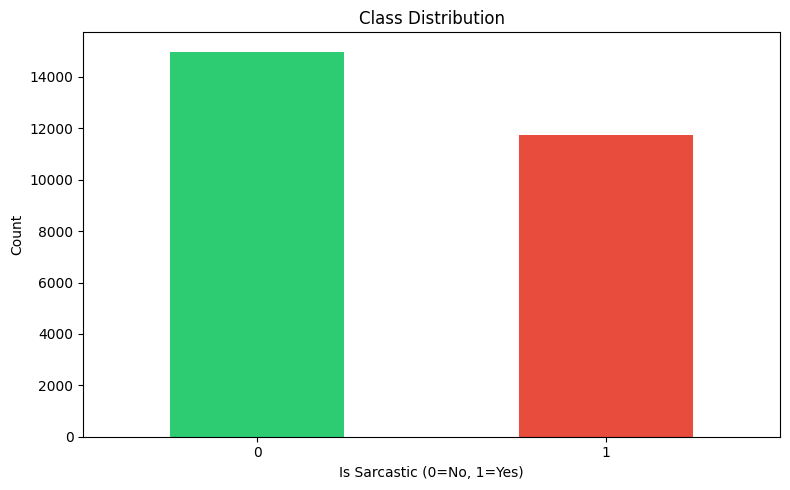

In [ ]:
class_dist = data['is_sarcastic'].value_counts()
print("Class Distribution")
print(class_dist)
print(f"\nBalance: {class_dist[1]/len(data)*100:.1f}% sarcastic, {class_dist[0]/len(data)*100:.1f}% non_sarcastic")

plt.figure(figsize=(8, 5))
class_dist.plot(kind='bar', color=['#2ecc72', '#e74c3c'])
plt.title('Class Distribution')
plt.xlabel('Is Sarcastic (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

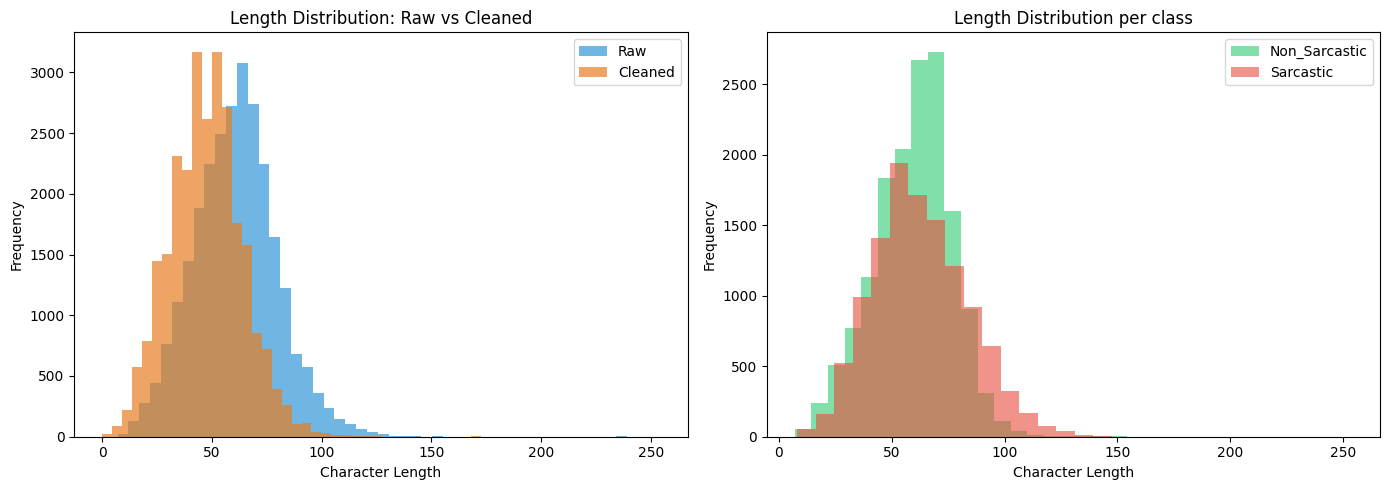

In [ ]:
data['length'] = data['headline'].apply(len)
data['clean_length'] = data['clean'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(data['length'], bins=50, alpha=0.7, label='Raw', color='#3498db')
axes[0].hist(data['clean_length'], bins=50, alpha=0.7, label='Cleaned', color='#e67e22')
axes[0].set_title('Length Distribution: Raw vs Cleaned')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(data[data['is_sarcastic']==0]['length'], bins=30, alpha=0.6, label='Non_Sarcastic', color='#2ecc71')
axes[1].hist(data[data['is_sarcastic']==1]['length'], bins=30, alpha=0.6, label='Sarcastic', color='#e74c3c')
axes[1].set_title('Length Distribution per class')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Frequency')
axes[1].legend()
plt.tight_layout()
plt.show()

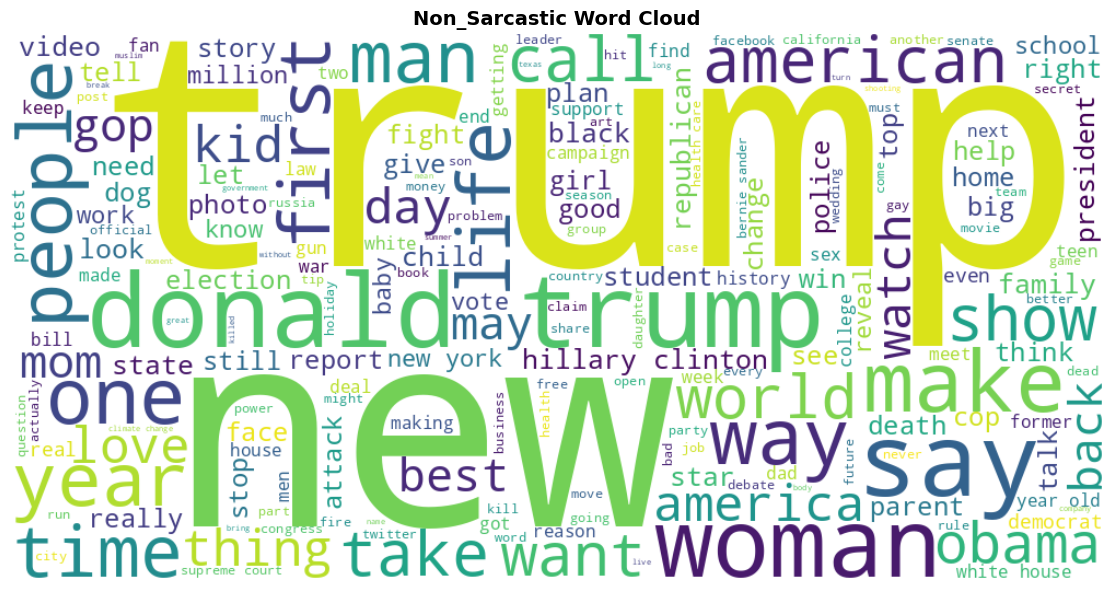

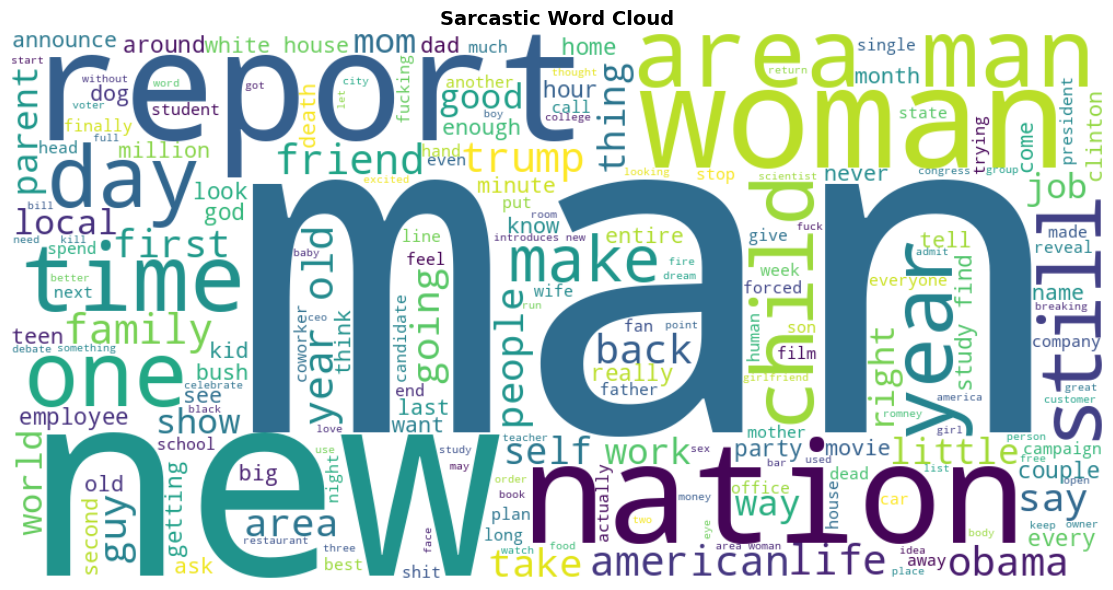

In [ ]:
def generate_wordcloud(texts, title):
  wc = WordCloud(width=1000, height=500, background_color='white',
                 colormap='viridis').generate(' '.join(texts))
  plt.figure(figsize=(12, 6))
  plt.imshow(wc, interpolation='bilinear')
  plt.axis('off')
  plt.title(title, fontsize=14, fontweight='bold')
  plt.tight_layout()
  plt.show()

generate_wordcloud(data[data['is_sarcastic']==0]['clean'], 'Non_Sarcastic Word Cloud')
generate_wordcloud(data[data['is_sarcastic']==1]['clean'], 'Sarcastic Word Cloud')

**Model 1: TF-IDF + Logistic Regression**

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = torch.FloatTensor(vectorizer.fit_transform(X_train).toarray())
X_test_tfidf = torch.FloatTensor(vectorizer.transform(X_test).toarray())
y_train_t = torch.FloatTensor(y_train.values)
y_test_t = torch.FloatTensor(y_test.values)

model_lr = nn.Sequential(nn.Linear(5000, 1))
optimizer = torch.optim.Adam(model_lr.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

for epoch in range(50):
  optimizer.zero_grad()
  loss = criterion(model_lr(X_train_tfidf).squeeze(), y_train_t)
  loss.backward()
  optimizer.step()

with torch.no_grad():
  y_pred_lr = (torch.sigmoid(model_lr(X_test_tfidf).squeeze()) > 0.5).numpy()

print(classification_report(y_test, y_pred_lr))
acc_lr, f1_lr = accuracy_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr)
print(f"Accuracy: {acc_lr:.4f} | F1: {f1_lr:.4f}\n")

              precision    recall  f1-score   support

           0       0.73      0.87      0.79      2997
           1       0.78      0.59      0.67      2345

    accuracy                           0.75      5342
   macro avg       0.75      0.73      0.73      5342
weighted avg       0.75      0.75      0.74      5342

Accuracy: 0.7473 | F1: 0.6738



* The TF-IDF (Pedregosa et al., 2011) and Logistic regression features are performed here in PyTorch.
* Converted the text data into numerical vectors using TF-IDF (Pedregosa et al., 2011) with feature dimension set as 5000.
* The logistic regression model (Hosmer, D. W., & Lemeshow, S., 2000)  is trained for 50 epochs using the Adam optimizer (Kingma, Diederik P and Ba, Jimmy Lei) and binary cross entropy loss.
* The `nn.sequential` class was used for create the logistic regression model.

**Model 2: Word2Vector + RNN**

In [ ]:
w2v = Word2Vec([t.split() for t in X_train], vector_size=100, window=5, workers=10, min_count=1, epochs=10)

def to_vec(texts, max_len=50):
    vecs = []
    for text in texts:
        vec = np.zeros((max_len, 100))
        for i, w in enumerate(text.split()[:max_len]):
            if w in w2v.wv: vec[i] = w2v.wv[w]
        vecs.append(vec.flatten())
    return torch.FloatTensor(vecs)

X_train_w2v = to_vec(X_train).view(-1, 50, 100)
X_test_w2v = to_vec(X_test).view(-1, 50, 100)

* The Word2Vec (Řehůřek & Sojka, 2010) based on Mikolov et al. (2013) model has been trained here to make 100-dimensional word vectors.
* The inputs were reshaped into 3-D vectors with the following dimensions: (batch, num_tokens, dimensions).
* `vector_size=100` for standard embedding dimension. `windows=5` captures +5 ans -5 woord context. `min_counr=1` includes all words. `epochs=10` sifficient for convergence on this corpus.



In [ ]:
class RNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.rnn = nn.LSTM(100, 128, 2, batch_first=True, dropout=0.3, bidirectional=True)
        self.fc = nn.Linear(256, 512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 1)

    def forward(self, x):
        _, (h, c) = self.rnn(x)
        hidden = torch.cat((h[-2], h[-1]), dim=1)
        out = self.fc(hidden)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

model_rnn = RNN().to('cuda')
model_rnn.train()
opt = torch.optim.Adam(model_rnn.parameters(), lr=0.0001)
loader = DataLoader(TensorDataset(X_train_w2v, y_train_t.unsqueeze(1)), batch_size=16, shuffle=True)

for epoch in tqdm.tqdm(range(50), desc="Training RNN"):
  for bx, by in loader:
    opt.zero_grad()
    loss = nn.BCEWithLogitsLoss()(model_rnn(bx.to('cuda')), by.to('cuda'))
    loss.backward()
    opt.step()

model_rnn.eval()
with torch.no_grad():
  y_pred_rnn = (torch.sigmoid(model_rnn(X_test_w2v.to('cuda'))) > 0.5).squeeze().cpu().numpy()

  print(classification_report(y_test, y_pred_rnn))
  acc_rnn,f1_rnn = accuracy_score(y_test, y_pred_rnn), f1_score(y_test, y_pred_rnn)
  print(f"Accuracy: {acc_rnn:.4f} | F1: {f1_rnn:.4f}\n")

Training RNN: 100%|██████████| 50/50 [05:29<00:00,  6.60s/it]


              precision    recall  f1-score   support

           0       0.71      0.82      0.76      2997
           1       0.71      0.58      0.64      2345

    accuracy                           0.71      5342
   macro avg       0.71      0.70      0.70      5342
weighted avg       0.71      0.71      0.71      5342

Accuracy: 0.7125 | F1: 0.6372



* The RNN (Hochreiter, S., & Schmidhuber, J., 1997 and Schuster, M., & Paliwal, K. K., 1997) architecture makes use of learned word embeddings as input and processes them sequentially through recurrent layers, allowing the network to capture contextual information by maintaining hidden states that accumulate knowledge from previously processed words
* `RNN` class was created by extending the `nn.module` class.
* Dataloader is created using the `dataloader` class with `batch_size` of 16 and `shuffle` set to True.
* The accuracy and the F1 score are also provided above.


**Model 3: BERT**

In [ ]:
tokenizer = BertTokenizer.from_pretrained('Bert-base-uncased')
model_bert = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

train_enc  = tokenizer(X_train.tolist(), truncation=True, padding=True, max_length=128)
test_enc = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length=128)

train_data = Dataset.from_dict({**train_enc, 'labels': y_train.tolist()})
test_data = Dataset.from_dict({**test_enc, 'labels': y_test.tolist()})

trainer = Trainer(model=model_bert, args=TrainingArguments(output_dir='./r', num_train_epochs=3, per_device_train_batch_size=16, eval_strategy="no", save_strategy="no", logging_steps=100), train_dataset=train_data)
trainer.train()
y_pred_bert = np.argmax(trainer.predict(test_data).predictions, axis=-1)

print(classification_report(y_test, y_pred_bert))
acc_bert, f1_bert = accuracy_score(y_test, y_pred_bert), f1_score(y_test, y_pred_bert)
print(f"Accuracy: {acc_bert:.4f} | F1: {f1_bert:.4f}\n")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Step,Training Loss
100,0.642200
200,0.576300
300,0.501500
400,0.490100
500,0.448800
600,0.463900
700,0.423800
800,0.413700
900,0.398000
1000,0.403700


              precision    recall  f1-score   support

           0       0.88      0.88      0.88      2997
           1       0.84      0.85      0.85      2345

    accuracy                           0.86      5342
   macro avg       0.86      0.86      0.86      5342
weighted avg       0.86      0.86      0.86      5342

Accuracy: 0.8647 | F1: 0.8462



* The `BertForSequenceClassification` (Devlin et al., 2019) model was imported from the HuggingFace `Transformers` library, along with its tokenizer `BertTokenizer`.
* The model was finetuned with the following hyperparameters: 3 `epochs`, `batch_size` of 16.
* BERT allows capturing complex contextual relationships and subject patterns to detect the sarcastic tone.
* The pre-trained model already possesses capabilty for understanding complex concepts due to the huge textual dataset acting as an ample amount of resource.

**Model Evaluation**

In [ ]:
results = pd.DataFrame({
    'Model': ['TF-IDF+LR', 'W2V+RNN', 'BERT'],
    'Accuracy': [acc_lr, acc_rnn, acc_bert],
    'F1': [f1_lr, f1_rnn, f1_bert]
})
print(results.to_string(index=False))
best = results.iloc[results['F1'].idxmax()]
print(f"\nBest: {best['Model']} | Acc: {best['Accuracy']:.4f} | F1: {best['F1']:.4f}")

    Model  Accuracy       F1
TF-IDF+LR  0.747286 0.673755
  W2V+RNN  0.712467 0.637222
     BERT  0.864657 0.846203

Best: BERT | Acc: 0.8647 | F1: 0.8462


* After getting the all accuracy values of different models we can see that BERT accuracy is better than others `86%`.
* Also, the TF_IDF+Logistic Regression model shows `74%` accuracy, and the worst performace was displayed by the Word2Vector+RNN model with `71%` accuracy.
* So, it is proven that the best model in the current case is the BERT model.
* Surprisingly, the Word2Vec+ RNN model produced lower than the more basic TF-IDF baseline. The reason is, may be the training data is limited or large dataset are required for neural networks.
* The RNN bad accuracy shows that it constantly overlooks the sarcastic headlines, probably because sequential processing fails to capture the non linear correlation that defines sarcasm.
* The baseline models accuracy shows that word frequency patterns alone provide a significant signal for sarcasm detection.
* The TF-IDF models precision recall gap suggests that it obtains accuracy mostly by properly detecting nin-sarcastic headlines yet struggling with sarcastic texts.

**Confusion Matrix**



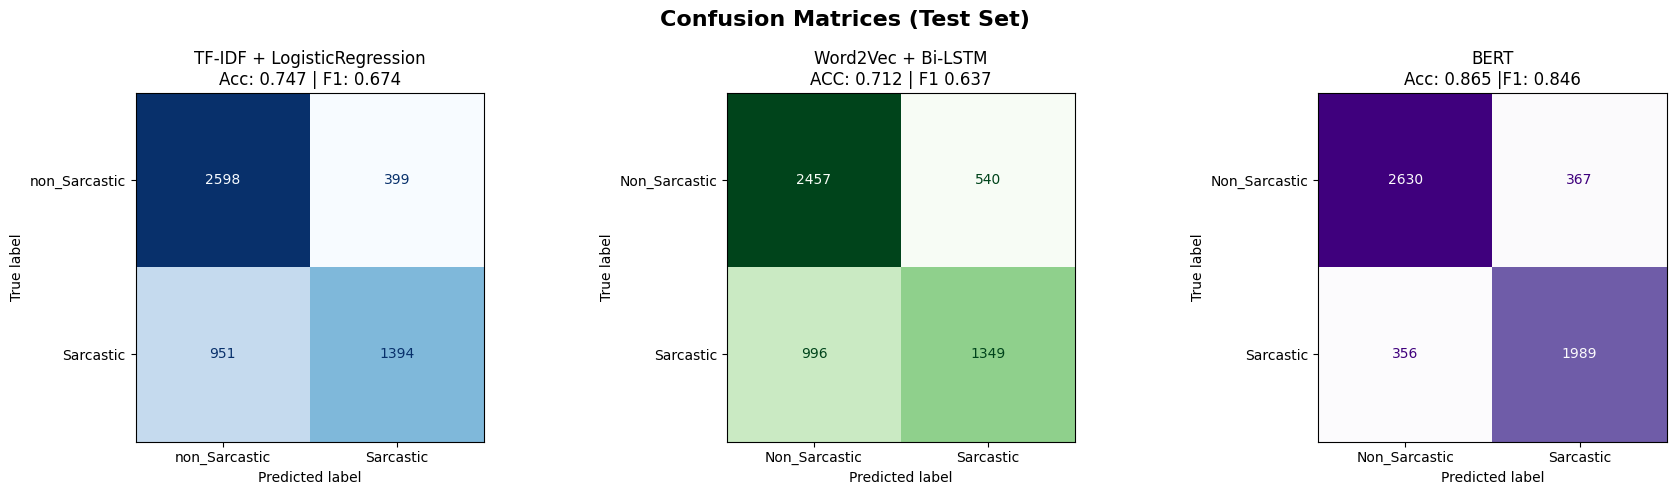

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices (Test Set)', fontsize=16, fontweight='bold')

cm1 = confusion_matrix(y_test, y_pred_lr)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=['non_Sarcastic', 'Sarcastic'])
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'TF-IDF + LogisticRegression\nAcc: {acc_lr:.3f} | F1: {f1_lr:.3f}')

cm2 = confusion_matrix(y_test, y_pred_rnn)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['Non_Sarcastic', 'Sarcastic'])
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'Word2Vec + Bi-LSTM\nACC: {acc_rnn:.3f} | F1 {f1_rnn:.3f}')

cm3 = confusion_matrix(y_test, y_pred_bert)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=['Non_Sarcastic', "Sarcastic"])
disp3.plot(ax=axes[2], cmap='Purples', colorbar=False)
axes[2].set_title(f'BERT\nAcc: {acc_bert:.3f} |F1: {f1_bert:.3f}')

plt.tight_layout()
plt.show()

**Final Remarks**

* The accuracy difference between BERT and other models emphasizes the transformational power of pre-trained language models on NLP tasks.
* The unexpected efficiency of TF-IDF shows that for many  actual applications, the higher computing of transformers may not justify the modest advantages.
* The selection of models should be directed by individual requirments and accuracy requirments against resource restictions.
* The study shows that being a difficult problem that requires complex language interpretation, sarcasm detection can be solved using contemporary NLP approches.

**Limitation**


* real world sarcasm is on a continuum, binary categorization oversimplifies.
* The trained model may not generalized to social media or conversational writing.
* While BERT delivers great accuracy which determine the factors drive prediction takes focused visualization.

**Recomendations**

* This model can be tested for Twitter sarcasm, Reddit comments and product reviews.


**Conclusion**

* For sarcasm detection it is really hard to understand the tone. Sometimes individuals are unable to understand the sarcasm.
* BERT is the clear winner here in this project. Its bidirectional architecture allows the model to understand the sentimental essence of a sarcastic talk. The BERT model achieved 86% accuracy and 0.8462 F1 score.
* TF-IDF + Logistic Regression baseline is solid and lightweight.
* There is a big difference for F1 score. Where TF-IDF + Logistic Regression showed 0.6737 and Word2Vec + RNN showed 0.6372.